In [1]:
# Базовые библиотеки
import os
import math
import time
import random
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms

from torchvision.models import resnet18, ResNet18_Weights


print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.11.0+cu130
torchvision: 0.26.0+cu130


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATASET_NAME = "CIFAR100"

FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"
ARTIFACTS_DIR = "./artifacts/"
FIGURES_DIR = ARTIFACTS_DIR + "figures/"

EPOCHS_CNN = 5 if FAST_MODE else 15
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

Device: cuda


In [3]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

BATCH_SIZE_CNN = 128
BATCH_SIZE_RN = 64

IMG_SIZE = 224


# transforms
train_tf_cnn = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4), 
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),  
])

eval_tf_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

train_tf_resnet = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])  

eval_tf_resnet = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])


# load datasets
def load_cifar100_cnn(data_dir: str = DATA_DIR):
    ds_train_aug  = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=train_tf_cnn)
    ds_train_eval = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=eval_tf_cnn)
    ds_test = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=eval_tf_cnn)
    return ds_train_aug, ds_train_eval, ds_test

def load_cifar100_resnet(data_dir: str = DATA_DIR):
    ds_train_aug  = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=train_tf_resnet)
    ds_train_eval = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=eval_tf_resnet)
    ds_test = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=eval_tf_resnet)
    return ds_train_aug, ds_train_eval, ds_test


ds_train_aug_cnn, ds_train_eval_cnn, ds_test_cnn = load_cifar100_cnn()
ds_train_aug_resnet, ds_train_eval_resnet, ds_test_resnet = load_cifar100_resnet()

class_names = ds_train_eval_cnn.classes

C:\Users\vnars\Desktop\AIE-course\pythonHW10-11\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
def make_loaders_cnn(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE_CNN,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,  
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    return train_loader, val_loader, test_loader


def make_loaders_no_aug(
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE_CNN,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE
):
    n_total = len(ds_train_eval)
    n_val = int(n_total * val_ratio)
    
    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)
    
    ds_train = Subset(ds_train_eval, indices[n_val:])
    ds_val = Subset(ds_train_eval, indices[:n_val])
    
    if fast_mode:
        ds_train = Subset(ds_train, rng.choice(len(ds_train), 4000, replace=False))
        ds_val = Subset(ds_val, rng.choice(len(ds_val), 1000, replace=False))
        ds_test = Subset(ds_test, rng.choice(len(ds_test), 1000, replace=False))
    
    return (DataLoader(ds_train, batch_size, shuffle=True, num_workers=8, pin_memory=True),
            DataLoader(ds_val, batch_size, shuffle=False, num_workers=8, pin_memory=True),
            DataLoader(ds_test, batch_size, shuffle=False, num_workers=8, pin_memory=True))

    
def make_loaders_resnet(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE_RN,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)

    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    return train_loader, val_loader, test_loader


train_loader_cnn, val_loader_cnn, test_loader_cnn = make_loaders_cnn(
    ds_train_aug_cnn, ds_train_eval_cnn, ds_test_cnn,
    #fast_mode=True,
)

x, y = next(iter(train_loader_cnn))
print("CNN - x:", x.shape, x.dtype)
print("CNN - y:", y.shape, y.dtype)

train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders_resnet(
    ds_train_aug_resnet, ds_train_eval_resnet, ds_test_resnet,
    #fast_mode=True
)

x, y = next(iter(train_loader_resnet))
print("ResNet - x:", x.shape, x.dtype)
print("ResNet - y:", y.shape, y.dtype)

C:\Users\vnars\Desktop\AIE-course\pythonHW10-11\.venv\Lib\site-packages\torch\utils\data\dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
C:\Users\vnars\Desktop\AIE-course\pythonHW10-11\.venv\Lib\site-packages\torch\utils\data\dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker n

CNN - x: torch.Size([128, 3, 32, 32]) torch.float32
CNN - y: torch.Size([128]) torch.int64
ResNet - x: torch.Size([64, 3, 224, 224]) torch.float32
ResNet - y: torch.Size([64]) torch.int64


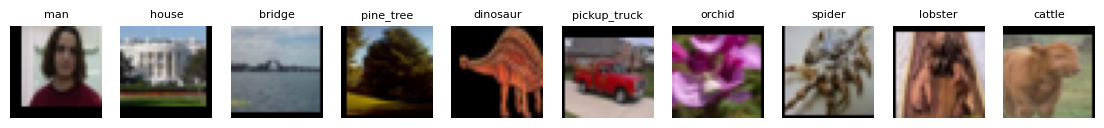

In [5]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10, save_path=None) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")

    if save_path:
        plt.savefig(save_path)
    plt.show()
    plt.close()

save_path = os.path.join(FIGURES_DIR, "augmentations_preview.png")
show_images(train_loader_cnn, n=10, save_path=save_path)

In [6]:
INPUT_DIM = 32 * 32 * 3
NUM_CLASSES = 100

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# модель CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=100, bias=True)
  )
)
Trainable params: 643492


In [7]:
# обучение
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"optimizer": optimizer, "criterion": criterion, "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

# график
def plot_history(hist: Dict[str, List[float]], title: str = "", save_name: str = None) -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    if save_name:
        plt.savefig(os.path.join(FIGURES_DIR, save_name))
    plt.show()

In [8]:
criterion = nn.CrossEntropyLoss()

def run_experiment_cnn(exp_id: str, model: nn.Module, type_of_train_data: str, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = 5):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    if type_of_train_data == 'aug':
        train_loader, val_loader, _ = make_loaders_cnn(ds_train_aug_cnn, ds_train_eval_cnn, ds_test_cnn)
    else:
        train_loader, val_loader, _ = make_loaders_no_aug(ds_train_eval_cnn, ds_test_cnn)
        
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}

runs = [] # для runs.csv


Experiment C1 | lr=0.001 weight_decay=0.0 epochs=15
Trainable params: 643492
Epoch 01/15 | train loss 3.7806, acc 0.123 | val loss 3.3029, acc 0.200 | 67.3s
Epoch 02/15 | train loss 3.0018, acc 0.261 | val loss 2.8579, acc 0.287 | 64.1s
Epoch 03/15 | train loss 2.6047, acc 0.337 | val loss 2.6102, acc 0.340 | 64.5s
Epoch 04/15 | train loss 2.3389, acc 0.394 | val loss 2.4484, acc 0.372 | 64.2s
Epoch 05/15 | train loss 2.1138, acc 0.443 | val loss 2.3767, acc 0.383 | 64.1s
Epoch 06/15 | train loss 1.9241, acc 0.484 | val loss 2.3790, acc 0.393 | 64.3s
Epoch 07/15 | train loss 1.7474, acc 0.526 | val loss 2.3698, acc 0.409 | 64.3s
Epoch 08/15 | train loss 1.5756, acc 0.565 | val loss 2.3948, acc 0.407 | 64.2s
Epoch 09/15 | train loss 1.4183, acc 0.604 | val loss 2.4356, acc 0.405 | 70.4s
Epoch 10/15 | train loss 1.2586, acc 0.642 | val loss 2.5986, acc 0.400 | 70.0s
Epoch 11/15 | train loss 1.1221, acc 0.678 | val loss 2.7491, acc 0.392 | 64.4s
Epoch 12/15 | train loss 0.9889, acc 0.707

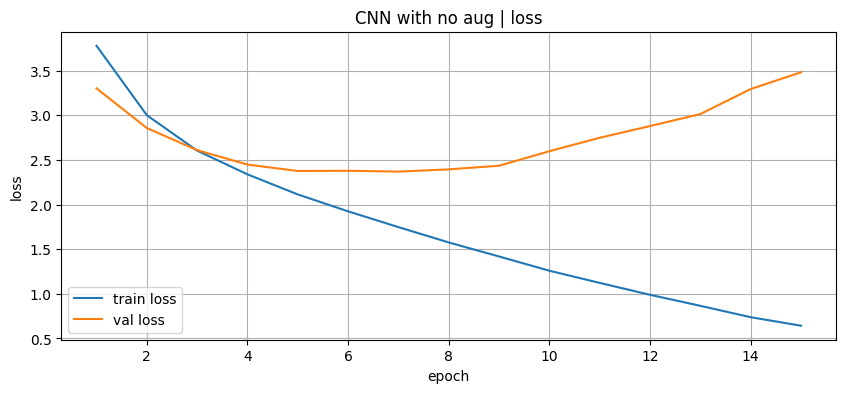

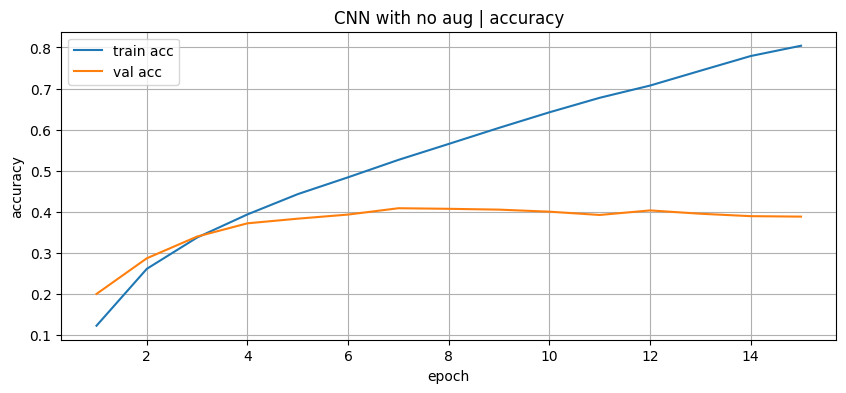

In [9]:
res_no_aug = run_experiment_cnn("C1", SimpleCNN(100), 'no_aug', epochs=EPOCHS_CNN)
plot_history(res_no_aug["history"], title="CNN with no aug")


Experiment C2 | lr=0.001 weight_decay=0.0 epochs=15
Trainable params: 643492
Epoch 01/15 | train loss 3.9703, acc 0.091 | val loss 3.5125, acc 0.160 | 65.3s
Epoch 02/15 | train loss 3.3643, acc 0.189 | val loss 3.0904, acc 0.235 | 64.5s
Epoch 03/15 | train loss 3.0487, acc 0.247 | val loss 2.8844, acc 0.279 | 64.6s
Epoch 04/15 | train loss 2.8563, acc 0.282 | val loss 2.7294, acc 0.311 | 64.5s
Epoch 05/15 | train loss 2.6956, acc 0.317 | val loss 2.6011, acc 0.343 | 64.6s
Epoch 06/15 | train loss 2.5740, acc 0.341 | val loss 2.4831, acc 0.360 | 64.7s
Epoch 07/15 | train loss 2.4672, acc 0.362 | val loss 2.4238, acc 0.372 | 64.9s
Epoch 08/15 | train loss 2.3772, acc 0.383 | val loss 2.3526, acc 0.386 | 64.7s
Epoch 09/15 | train loss 2.2959, acc 0.400 | val loss 2.3605, acc 0.385 | 64.5s
Epoch 10/15 | train loss 2.2325, acc 0.412 | val loss 2.2550, acc 0.410 | 64.8s
Epoch 11/15 | train loss 2.1759, acc 0.425 | val loss 2.2930, acc 0.403 | 65.1s
Epoch 12/15 | train loss 2.1201, acc 0.436

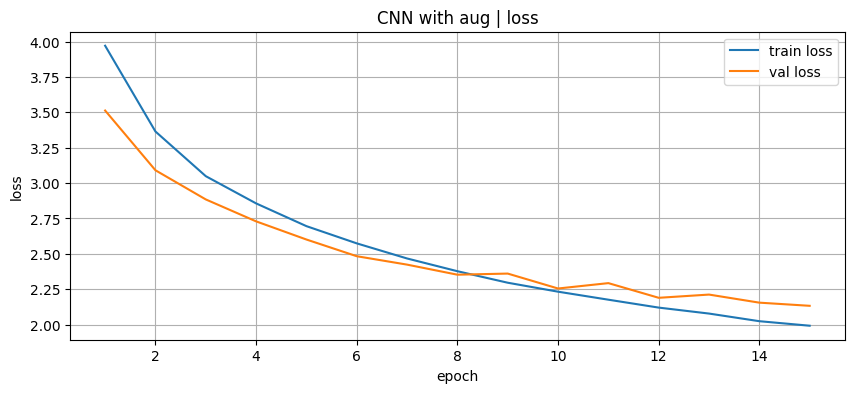

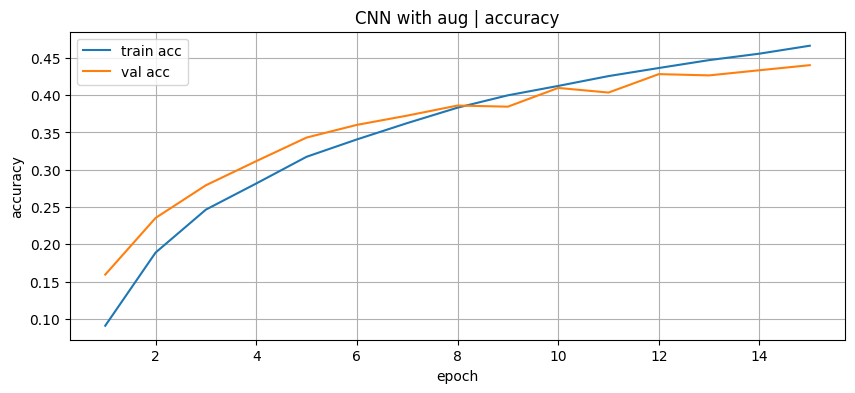

In [10]:
res_aug = run_experiment_cnn("C2", SimpleCNN(100), 'aug', epochs=EPOCHS_CNN)
plot_history(res_aug["history"], title="CNN with aug")

In [11]:
# часть ResNet

def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [12]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# создание модели ResNet
def build_resnet18(num_classes: int, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model_resnet18 = build_resnet18(num_classes=NUM_CLASSES, weights=weights).to(DEVICE)
print(model_resnet18)
print("Trainable params:", count_trainable_params(model_resnet18))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
def run_experiment_resnet(exp_id: str, model: nn.Module, optimizer, epochs: int = 5):
    print("=" * 80)
    print(f"Experiment {exp_id}")
    print("Trainable params:", count_params(model))
    
    train_loader, val_loader, _ = make_loaders_resnet(ds_train_aug_resnet, ds_train_eval_resnet, ds_test_resnet)
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}


Phase 1: head-only training
Experiment C3
Trainable params: 51300
Epoch 01/8 | train loss 2.6906, acc 0.364 | val loss 2.0497, acc 0.468 | 116.1s
Epoch 02/8 | train loss 1.8802, acc 0.505 | val loss 1.8581, acc 0.506 | 118.7s
Epoch 03/8 | train loss 1.7396, acc 0.529 | val loss 1.8010, acc 0.513 | 119.7s
Epoch 04/8 | train loss 1.6671, acc 0.544 | val loss 1.7667, acc 0.522 | 119.1s
Epoch 05/8 | train loss 1.6231, acc 0.553 | val loss 1.7381, acc 0.528 | 120.8s
Epoch 06/8 | train loss 1.5960, acc 0.560 | val loss 1.7140, acc 0.534 | 119.2s
Epoch 07/8 | train loss 1.5752, acc 0.565 | val loss 1.7137, acc 0.532 | 122.2s
Epoch 08/8 | train loss 1.5555, acc 0.570 | val loss 1.7066, acc 0.532 | 120.0s


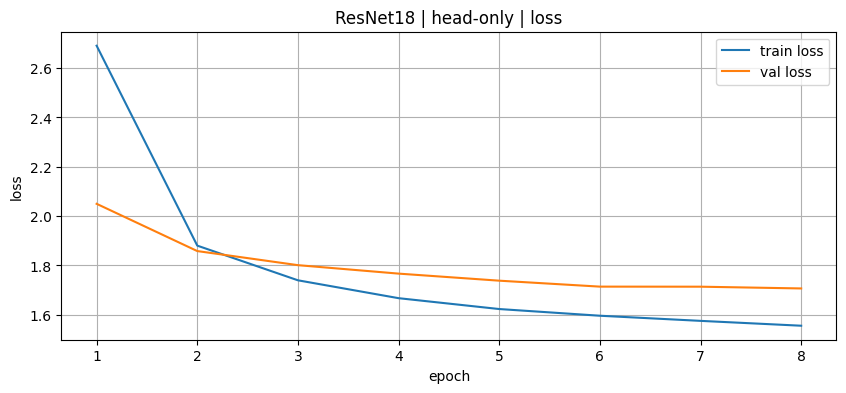

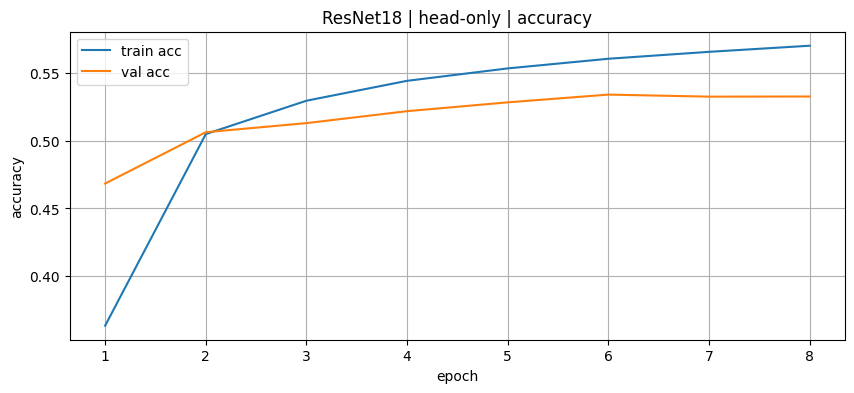

In [14]:
# freeze всё
set_requires_grad(model_resnet18, False)
# размораживаем только голову
set_requires_grad(model_resnet18.fc, True)

optimizer_head = torch.optim.Adam(model_resnet18.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = run_experiment_resnet("C3", model_resnet18, optimizer_head, epochs=EPOCHS_HEAD)
plot_history(hist_head["history"], title="ResNet18 | head-only")


Phase 2: fine-tuning layer4 + fc
Experiment C4
Trainable params: 8445028
Epoch 01/8 | train loss 1.3705, acc 0.615 | val loss 1.2977, acc 0.636 | 130.5s
Epoch 02/8 | train loss 0.9993, acc 0.703 | val loss 1.2213, acc 0.665 | 131.7s
Epoch 03/8 | train loss 0.8324, acc 0.748 | val loss 1.2238, acc 0.659 | 131.0s
Epoch 04/8 | train loss 0.7148, acc 0.780 | val loss 1.2113, acc 0.675 | 131.0s
Epoch 05/8 | train loss 0.6018, acc 0.812 | val loss 1.1966, acc 0.684 | 131.0s
Epoch 06/8 | train loss 0.5205, acc 0.837 | val loss 1.1893, acc 0.688 | 131.2s
Epoch 07/8 | train loss 0.4544, acc 0.858 | val loss 1.1938, acc 0.689 | 130.5s
Epoch 08/8 | train loss 0.3982, acc 0.874 | val loss 1.2537, acc 0.693 | 133.6s


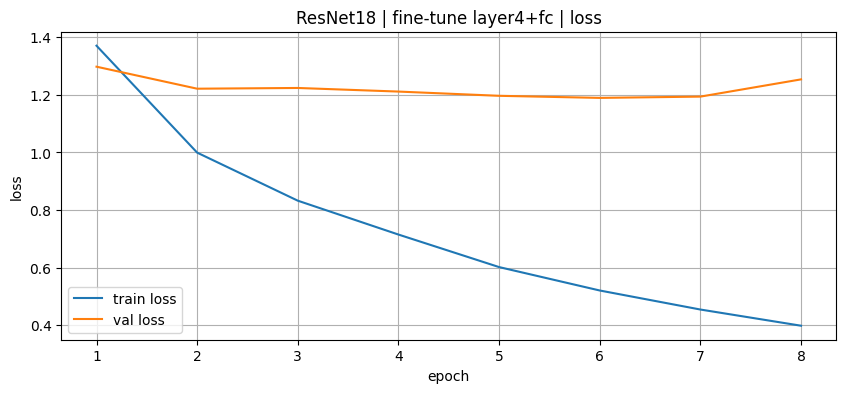

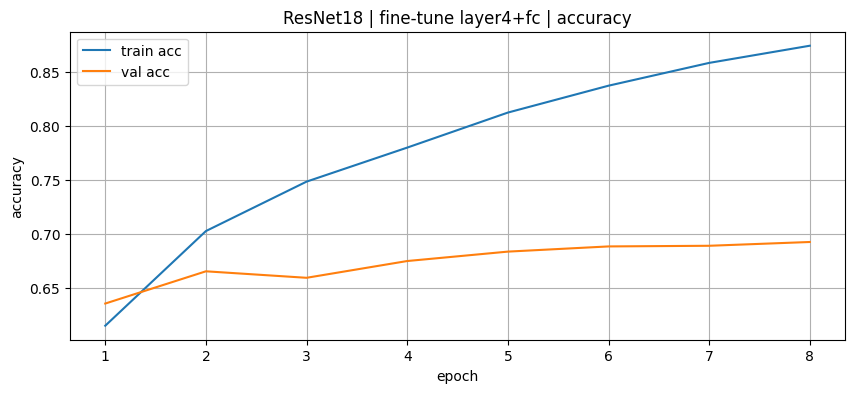

In [15]:
# размораживаем layer4 и fc
set_requires_grad(model_resnet18.layer4, True)
set_requires_grad(model_resnet18.fc, True)

params = [
    {"params": model_resnet18.layer4.parameters(), "lr": 1e-4},
    {"params": model_resnet18.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = run_experiment_resnet("C4", model_resnet18, optimizer_ft, epochs=EPOCHS_HEAD)
plot_history(hist_ft["history"], title="ResNet18 | fine-tune layer4+fc")

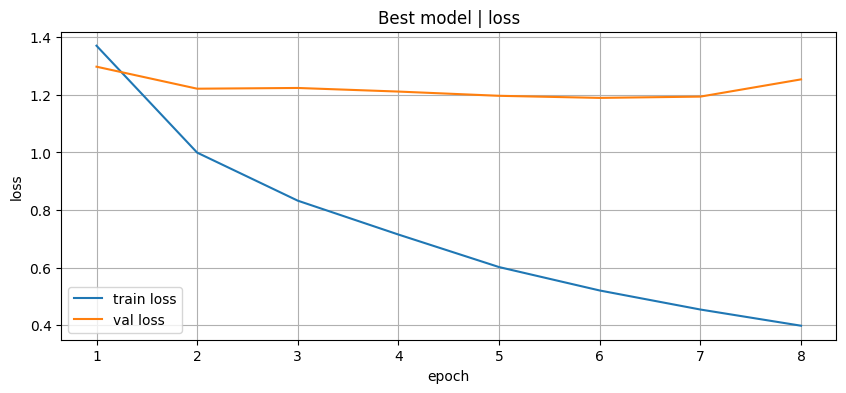

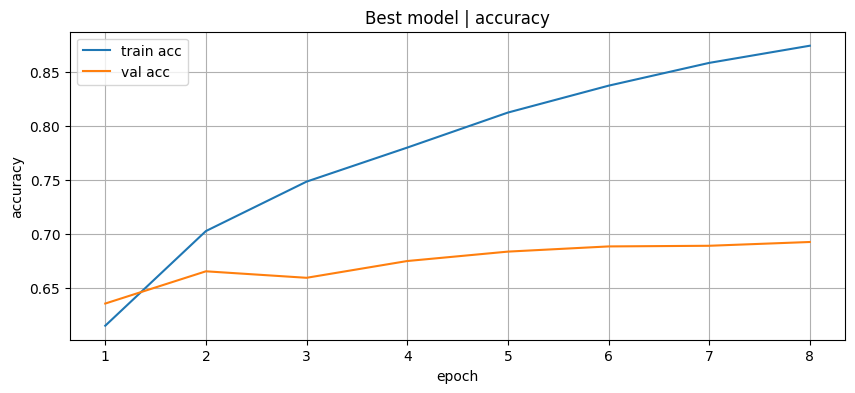

Test loss: 1.2640
Test accuracy: 0.6825


In [17]:
# список всех созданных моделей
all_results = {
        'no_aug': res_no_aug,
        'aug': res_aug,
        'head': hist_head,
        'fine_tune': hist_ft,
    }

# выбор лучшей модели по val_acc
def get_best_model(all_results):
    best_result = max(all_results.values(), key=lambda x: max(x["history"]["val_acc"]))
    return best_result

# выдает данные об модели в формате json
def get_model_json(model, optimizer, dataset=DATASET_NAME, seed=RANDOM_STATE):
    opt_params = optimizer.param_groups[0]
    return {
        "dataset": dataset,
        "seed": seed,
        "fast_mode": FAST_MODE,
        "mean": CIFAR100_MEAN,
        "std": CIFAR100_STD,
        #"num_classes": model.num_classes,
        "exp": model["exp_id"],
        "optimizer": type(optimizer).__name__,
        "epochs": len(model["history"]["val_acc"]),
        "best_val_accuracy": float(np.max(model["history"]["val_acc"])),
        "best_val_loss": float(np.min(model["history"]["val_loss"]))
    }


best_model_cfg = get_best_model(all_results)
best_model = best_model_cfg["model"]
# сохранение графика лучшей модели
plot_history(best_model_cfg["history"], title="Best model", save_name = "classification_curves_best")

# тест прогон лучшей модели
test_loss, test_acc = evaluate(best_model, test_loader_resnet, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# сохранение best_model.pt
torch.save(best_model.state_dict(), os.path.join(ARTIFACTS_DIR, "best_model.pt"))

# сохранение best_config.json
best_config = get_model_json(best_model_cfg, optimizer_ft)
with open(os.path.join(ARTIFACTS_DIR, "best_config.json"), "w") as f:
    json.dump(best_config, f, indent=4)

In [18]:
# сохранение данных об модели в массив runs
def save_results_runs(res_list, model, task, summary, optimizer, lr, epochs, notes,
                          dataset=DATASET_NAME, seed=RANDOM_STATE,
                          test_acc =None, test_loss=None):
    
    opt = type(model["history"]["optimizer"]).__name__, # вынимаем optimizer 
    res_list.append({
        "experiment_id": model["exp_id"],
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "model_summary": summary,
        "optimizer": opt,
        "lr": lr,
        "epochs_trained": len(model["history"]["val_acc"]),
        "best_val_accuracy": max(model["history"]["val_acc"]),
        "best_val_loss": min(model["history"]["val_loss"]),
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": notes,
    })


# сохранения в runs.csv
def save_runs_csv(res, path):
    df = pd.DataFrame(res)
    df.to_csv(path, index=False)
    print(f"Results saved to {path}")
    return df

runs = []

save_results_runs(
    runs, res_no_aug, "classification", "SimpleCNN no aug", "Adam", 0.001, EPOCHS_CNN, "Simple CNN without augmentations"
)

save_results_runs(
    runs, res_aug, "classification", "SimpleCNN with aug", "Adam", 0.001, EPOCHS_CNN, "Simple CNN with augmentations"
)

save_results_runs(
    runs, hist_head, "classification", "ResNet18 head-only", "Adam", 0.001, EPOCHS_HEAD, "Pretrained ResNet18 backbone frozen"
)

save_results_runs(
    runs, hist_ft, "classification", "ResNet18 fine-tune", "Adam", "layer4:1e-4 fc:1e-3", EPOCHS_FT,
    "Pretrained ResNet18 fine-tuning layer4 and fc", test_acc=test_acc, test_loss=test_loss,
)

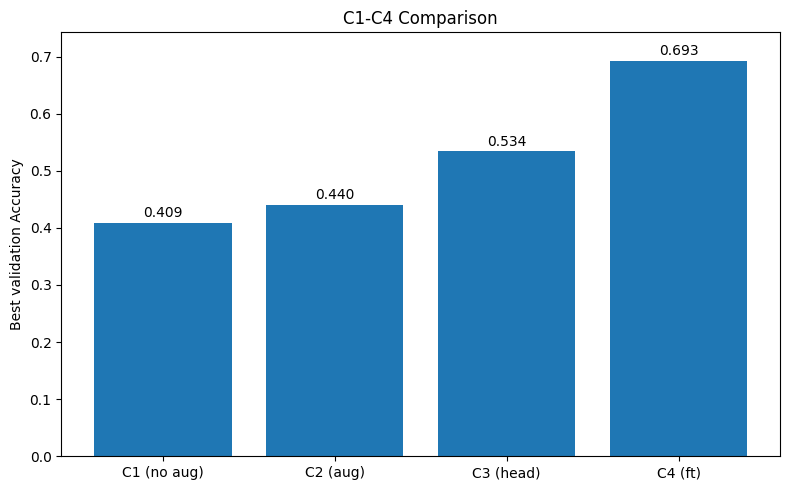

In [19]:
# построение графика сравнения метрик val_acc всех модеелей
exp_names = ["C1 (no aug)", "C2 (aug)", "C3 (head)", "C4 (ft)"]
best_accs = [
    max(res_no_aug["history"]["val_acc"]),
    max(res_aug["history"]["val_acc"]),
    max(hist_head["history"]["val_acc"]),
    max(hist_ft["history"]["val_acc"])
]

plt.figure(figsize=(8, 5))
bars = plt.bar(exp_names, best_accs)
plt.ylim(0, max(best_accs) + 0.05)
plt.ylabel("Best validation Accuracy")
plt.title("C1-C4 Comparison")

for bar, val in zip(bars, best_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "classification_compare.png"))
plt.show()

# ЧАСТЬ B

In [20]:
import shutil
from dataclasses import dataclass
from torchvision.datasets.utils import download_and_extract_archive
from PIL import Image

# Конфигурация
@dataclass
class RunConfig:
    data_dir: str = DATA_DIR
    fast_mode: bool = True
    n_show: int = 3
    aeroplane_only: bool = True  # мы считаем IoU только по классу "aeroplane"

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=3, aeroplane_only=True)

In [21]:
# Данные: Pascal VOC

VOC_URL = "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"

def ensure_pennfudan(root: str) -> str:
    voc_root = root + "/VOCdevkit/" + "VOC2012/"
    if os.path.isdir(voc_root):
        return voc_root

    os.makedirs(root, exist_ok=True)

    try:
        print("Downloading Pascal VOC to:", root)
        download_and_extract_archive(
            VOC_URL,
            download_root=root,
            filename="VOCtrainval_11-May-2012.tar",
            remove_finished=False
        )
        if not os.path.isdir(voc_root):
            raise FileNotFoundError("VOC2012 не найден после распаковки")
        return voc_root
        
    except Exception as e:
        print("Не удалось автоматически скачать датасет.")
        print("Ошибка:", repr(e))
        print("\nВариант вручную:")
        print(f"1) скачайте {VOC_URL}")
        print(f"2) распакуйте так, чтобы было: {voc_root}/JPEGImages и {voc_root}/SegmentationClass")
        raise

voc_root = ensure_pennfudan(cfg.data_dir)
voc_root

'./data/VOCdevkit/VOC2012/'

In [22]:
# Dataset для сегментации

#import torch.utils.data

class VOCSegDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "JPEGImages")
        self.mask_dir = os.path.join(root, "SegmentationClass")

        split_file = os.path.join(root, "ImageSets", "Segmentation", "train.txt")

        with open(split_file) as f:
            self.ids = [line.strip() for line in f]

        self.imgs = [f"{id}.jpg" for id in self.ids]
        self.masks = [f"{id}.png" for id in self.ids]

        if len(self.imgs) == 0:# or len(self.imgs) != len(self.masks):
            raise RuntimeError("Похоже, структура VOC повреждена или не распакована полностью.")

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        
        if mask.size != img.size:
            mask = mask.resize(img.size, Image.NEAREST)
            
        mask_np = np.array(mask)
        mask_np[mask_np == 255] = 0
        gt = (mask_np == 1).astype(np.uint8)

        return img, gt  # img = PIL, gt = numpy

dataset = VOCSegDataset(voc_root)
len(dataset), dataset[0][0].size, dataset[0][1].shape

(1464, (500, 281), (281, 500))

In [23]:
# Модель: DeepLabV3 (COCO-with-VOC-labels) + поиск индекса класса "aeroplane"

import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta.get("categories", None)

if categories is None:
    raise RuntimeError("В weights.meta нет списка categories – сложно найти индекс 'aeroplane' динамически.")

if "aeroplane" not in categories:
    raise RuntimeError("В categories нет класса 'aeroplane'. Проверьте, какие веса вы загрузили.")

TARGET_IDX = categories.index("aeroplane")
print("num_classes:", len(categories))
print("TARGET_IDX:", TARGET_IDX)

# Трансформации, соответствующие обучению этих весов
preprocess = weights.transforms()
preprocess

num_classes: 21
TARGET_IDX: 1


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [26]:
# Инференс + IoU
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode
import cv2


@torch.no_grad()
def predict_target_mask(img_pil: Image.Image) -> torch.Tensor:
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)  # [1,3,H,W]
    out = model(x)["out"][0]  # [C,H,W]
    pred = out.argmax(0)      # [H,W]
    target = (pred == int(TARGET_IDX)).to(torch.uint8)
    return target.cpu(), x.shape[-2:]  # (mask, (H,W))

def postprocess_v2(mask: torch.Tensor) -> torch.Tensor:
    mask_np = mask.numpy().astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_np, connectivity=8)

    new_mask = np.zeros_like(mask_np)

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > 300:
            new_mask[labels == i] = 1

    return torch.from_numpy(new_mask)

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def eval_subset(indices: List[int], use_v2: bool = False) -> Dict[str, float]:
    ious = []

    for idx in indices:
        img_pil, gt_np = dataset[idx]
        pred_mask, (h, w) = predict_target_mask(img_pil)

        if use_v2:
            pred_mask = postprocess_v2(pred_mask)

        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))
        
    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

def has_aeroplane(gt):
    return gt.sum() > 0

filtered_indices = []
for i in range(len(dataset)):
    _, gt = dataset[i]
    if has_aeroplane(gt):
        filtered_indices.append(i)

eval_indices = filtered_indices[:20]

In [27]:
metrics_v1 = eval_subset(eval_indices, use_v2=False)
print(metrics_v1)
metrics_v2 = eval_subset(eval_indices, use_v2=True)
print(metrics_v2)

{'n': 20.0, 'mean_IoU': 0.6909817119228159, 'median_IoU': 0.7753880816451562, 'min_IoU': 0.0, 'max_IoU': 0.9547278113813011}
{'n': 20.0, 'mean_IoU': 0.6907382612708503, 'median_IoU': 0.7753880816451562, 'min_IoU': 0.0, 'max_IoU': 0.9547278113813011}


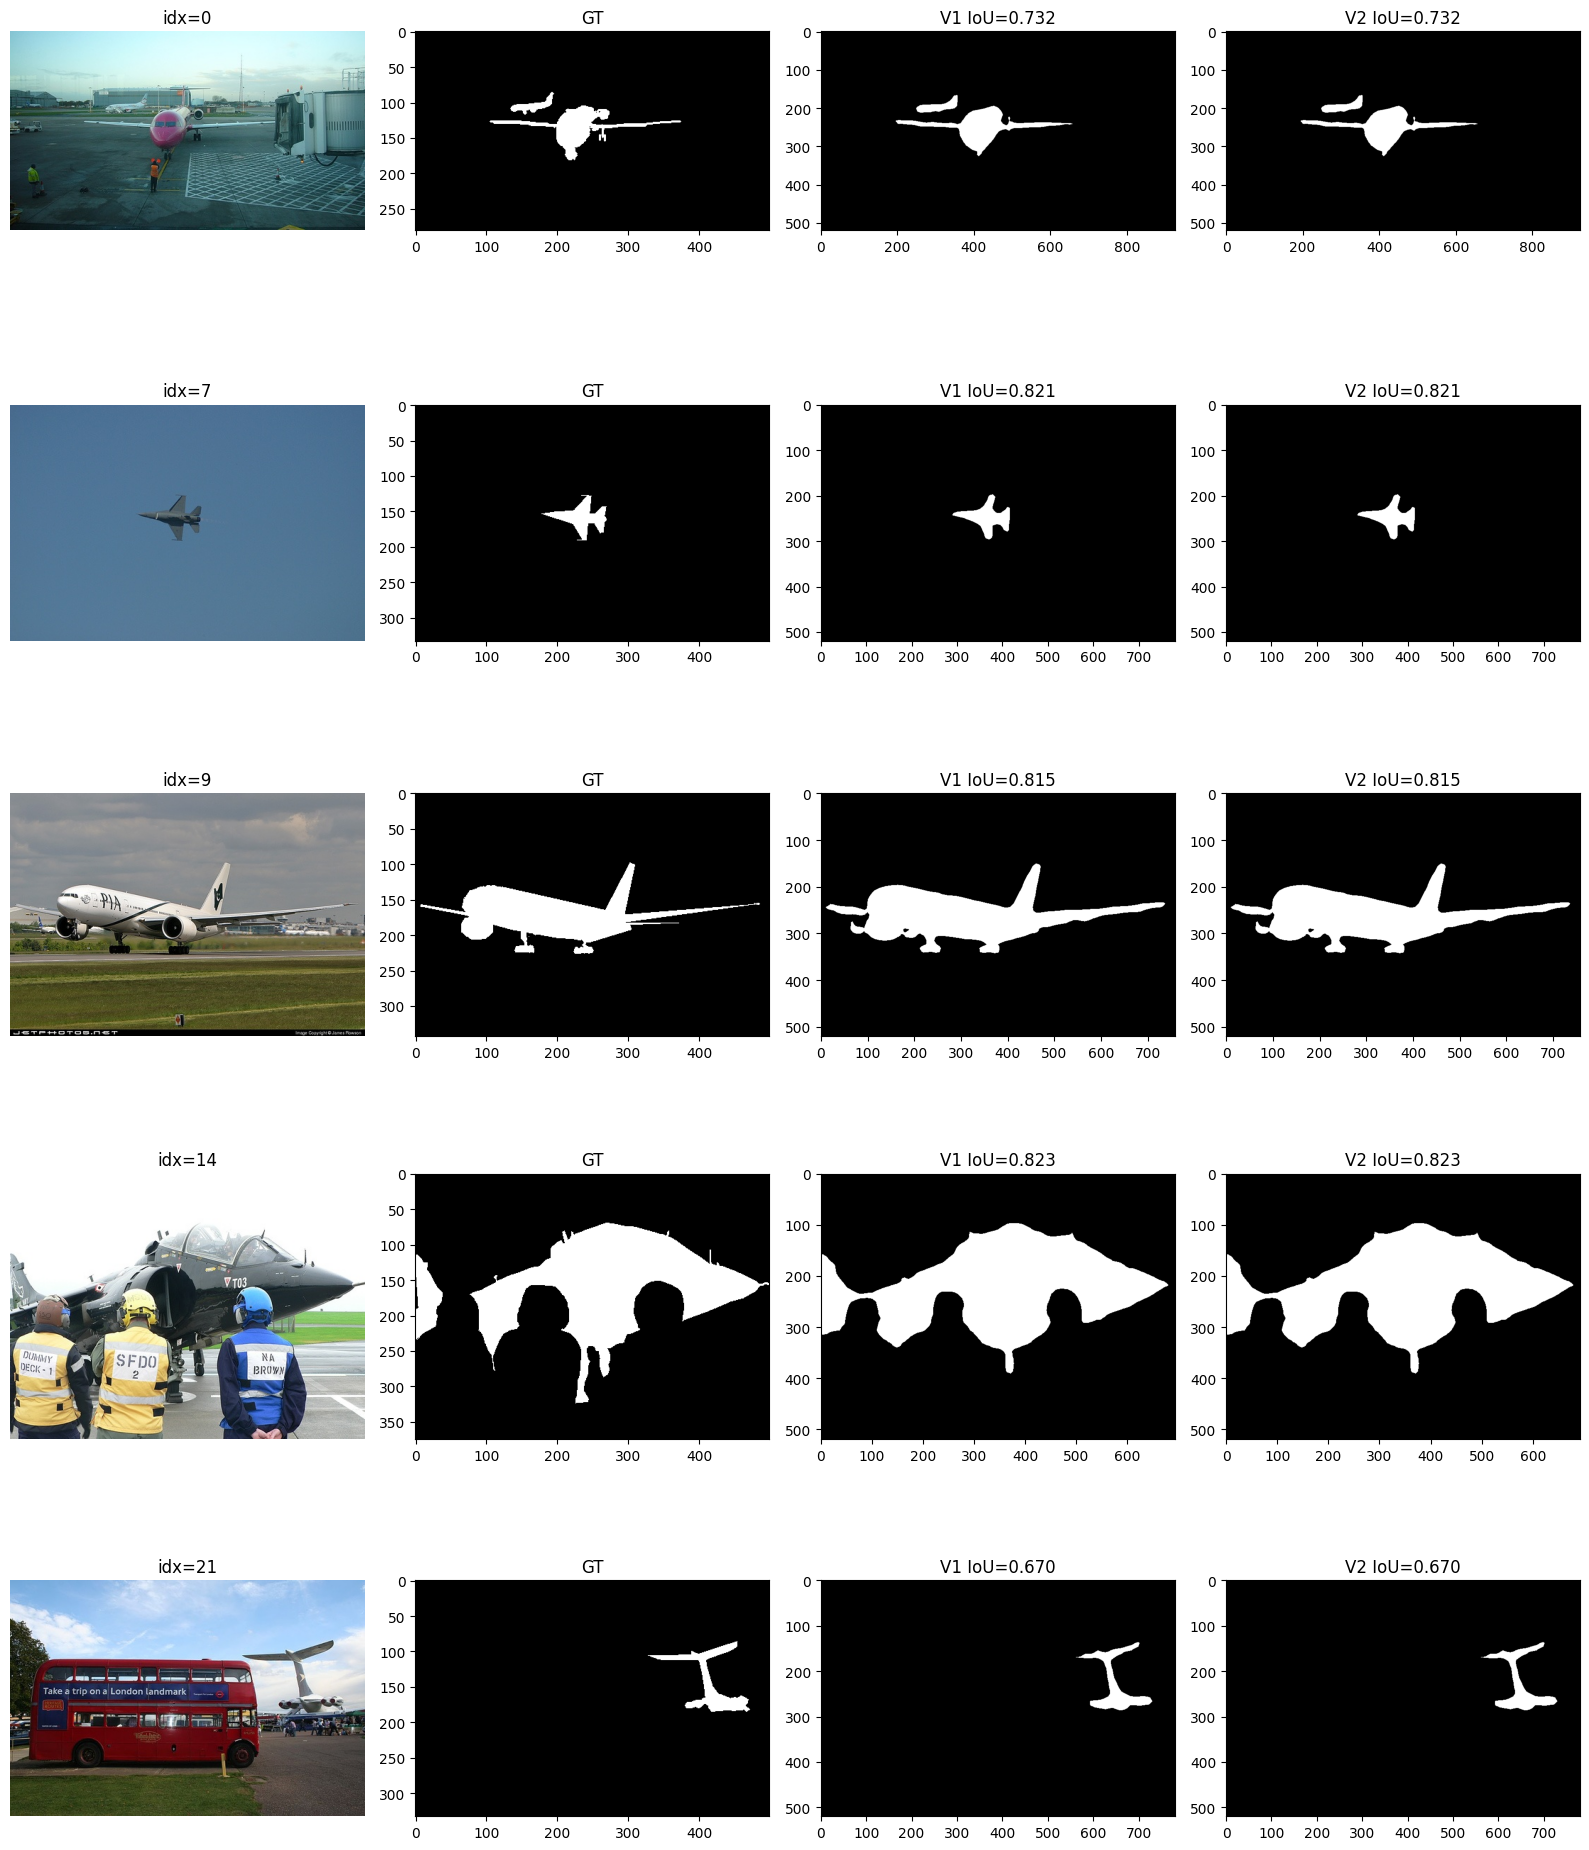

In [28]:
# Визуализация: image / GT / pred
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

n = min(5, len(dataset)) 
fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    idx = filtered_indices[row]
    img_pil, gt_binary = dataset[idx]

    pred_v1, (h, w) = predict_target_mask(img_pil)
    pred_v2 = postprocess_v2(pred_v1)

    gt_pil = Image.fromarray((gt_binary * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou_v1 = iou_binary(pred_v1, gt_mask)
    iou_v2 = iou_binary(pred_v2, gt_mask)

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"idx={idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_binary, cmap="gray")
    axes[row, 1].set_title("GT")

    axes[row, 2].imshow(pred_v1.numpy(), cmap="gray")
    axes[row, 2].set_title(f"V1 IoU={iou_v1:.3f}")

    axes[row, 3].imshow(pred_v2.numpy(), cmap="gray")
    axes[row, 3].set_title(f"V2 IoU={iou_v2:.3f}")

plt.tight_layout()
os.path.join(FIGURES_DIR, "segmentation_examples.png")
plt.savefig(os.path.join(FIGURES_DIR, "segmentation_examples.png"))
plt.show()

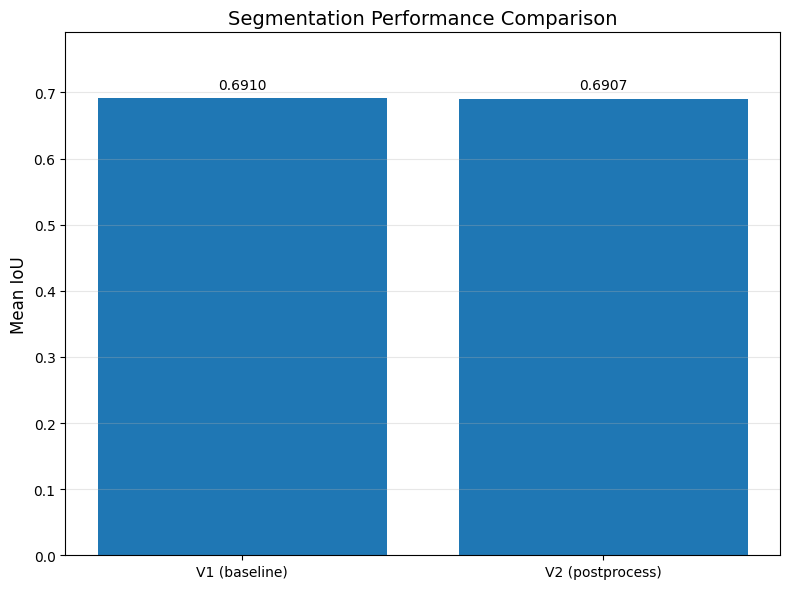

In [29]:
# построение графика V1 и V2 по Mean IoU

plt.figure(figsize=(8, 6))

methods = ['V1 (baseline)', 'V2 (postprocess)']
ious = [metrics_v1["mean_IoU"], metrics_v2["mean_IoU"]]

bars = plt.bar(methods, ious)

plt.ylabel('Mean IoU', fontsize=12)
plt.title('Segmentation Performance Comparison', fontsize=14)

plt.ylim(0, max(ious) + 0.1 if max(ious) > 0 else 1.0)

for bar, val in zip(bars, ious):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.4f}',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "segmentation_metrics.png"))
plt.show()

In [30]:
# сохранение данных об модели (V1/V2) в массив
def save_results_runs(res_list, exp_id, task, dataset, 
                      summary, mean_iou, notes, 
                      seed = RANDOM_STATE):
    res_list.append({
        "experiment_id": exp_id,
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "model_summary": summary,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_accuracy": None,
        "best_val_loss": None,
        "test_accuracy": None,
        "test_loss": None,
        "precision": None,
        "recall": None,
        "mean_iou": mean_iou,
        "notes": notes,
    })
    return res_list

In [31]:
save_results_runs(
    runs, "V1", "segmentation", "Pascal VOC", 
    "DeepLabV3_ResNet50", f"{metrics_v1["mean_IoU"]:.6f}", "Baseline"
)

save_results_runs(
    runs, "V2", "segmentation", "Pascal VOC", 
    "DeepLabV3_ResNet50", f"{metrics_v2["mean_IoU"]:.6f}", "Postprocess"
)

save_runs_csv(runs, os.path.join(ARTIFACTS_DIR, "runs.csv"))

Results saved to ./artifacts/runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,best_val_loss,test_accuracy,test_loss,precision,recall,mean_iou,notes
0,C1,classification,CIFAR100,42,SimpleCNN no aug,"(Adam,)",0.001,15.0,0.4087,2.369766,NaN,NaN,None,None,NaN,Simple CNN without augmentations
1,C2,classification,CIFAR100,42,SimpleCNN with aug,"(Adam,)",0.001,15.0,0.4401,2.132768,NaN,NaN,None,None,NaN,Simple CNN with augmentations
2,C3,classification,CIFAR100,42,ResNet18 head-only,"(Adam,)",0.001,8.0,0.5338,1.706594,NaN,NaN,None,None,NaN,Pretrained ResNet18 backbone frozen
3,C4,classification,CIFAR100,42,ResNet18 fine-tune,"(Adam,)",layer4:1e-4 fc:1e-3,8.0,0.6925,1.189333,0.6825,1.263957,None,None,NaN,Pretrained ResNet18 fine-tuning layer4 and fc
4,V1,segmentation,Pascal VOC,42,DeepLabV3_ResNet50,None,None,NaN,NaN,NaN,NaN,NaN,None,None,0.690982,Baseline
5,V2,segmentation,Pascal VOC,42,DeepLabV3_ResNet50,None,None,NaN,NaN,NaN,NaN,NaN,None,None,0.690738,Postprocess
